In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../raw/listings.csv")

df

,locality,property_type,subtype,price_eur,type_of_sale,num_rooms,living_area_m2,fully_equipped_kitchen,furnished,terrace,terrace_area_m2,garden,garden_area_m2,land_surface_m2,num_facades,swimming_pool,state_of_building,num_bathrooms,dist_train_km,dist_bus_km
0,7130 Binche,House,Villa,785000.0,for sale,5.0,450.0,1.0,NaN,1.0,NaN,1.0,NaN,12700.0,4.0,NaN,NaN,3.0,5.000,0.514
1,3190 Boortmeerbeek,House,Residence,498000.0,for sale,4.0,171.0,NaN,0.0,1.0,NaN,1.0,NaN,400.0,3.0,NaN,Normal,2.0,1.500,0.750
2,2350 Vosselaar,House,Residence,285000.0,for sale,2.0,128.0,NaN,0.0,0.0,NaN,1.0,NaN,189.0,3.0,NaN,Normal,1.0,3.700,0.591
3,4460 Grâce-Hollogne,House,Residence,119000.0,for sale,2.0,95.0,NaN,0.0,0.0,NaN,0.0,NaN,31.0,3.0,0.0,To renovate,1.0,4.300,0.321
4,1420 Braine-l'Alleud,House,Residence,565000.0,for sale,4.0,175.0,NaN,NaN,1.0,30.0,1.0,200.0,NaN,2.0,NaN,Excellent,NaN,1.800,1.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26344,9420 Aaigem,House,Residence,525000.0,for sale,4.0,295.0,NaN,0.0,1.0,50.0,1.0,1500.0,NaN,NaN,0.0,Normal,2.0,3.100,0.724
26345,3650 Dilsen,House,Residence,225000.0,for sale,3.0,165.0,NaN,NaN,1.0,NaN,1.0,306.0,535.0,3.0,0.0,To be renovated,NaN,NaN,0.078
26346,9000 Gent,Apartment,Studio,220000.0,for sale,NaN,25.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,2.0,NaN,Excellent,NaN,1.300,0.076
26347,2640 Mortsel,Apartment,Apartment,195000.0,for sale,2.0,78.0,NaN,0.0,1.0,NaN,0.0,NaN,NaN,2.0,NaN,To be renovated,NaN,0.760,1.600


STEP 2 : DATA ANALYSIS

In [3]:
#How many rows and columns 
df = df.drop_duplicates()

In [4]:
#Data cleaning


df = df[(df["living_area_m2"] > 20) & (df["price_eur"] > 10000) &  (df["num_rooms"] > 0)]

# 1 = HOUSE, 0 = APARTMENT/OTHERS
df["is_house"] = (df["property_type"].str.upper() == "HOUSE").astype(int)

#Spliting postal code and municipality 
df[["postal_code", "municipality"]] = df["locality"].str.split(" ", n=1, expand=True)
df["postal_code"] = df["postal_code"].astype(int)


#No garden no m2/No terrace no m2
df.loc[df['garden'] == 0, 'garden_area_m2'] = 0
df.loc[df['terrace'] == 0, 'terrace_area_m2'] = 0

#Remove localities with less than 10 properties
df= df.groupby("municipality").filter(lambda x: len(x) > 10)

df["fully_equipped_kitchen"] = df["fully_equipped_kitchen"].fillna(0)
df["swimming_pool"] = df["swimming_pool"].fillna(0)
df["furnished"] = df["furnished"].fillna(0)
df["land_surface_m2"] = df["land_surface_m2"].fillna(0)
df["land_surface_m2"] = df["land_surface_m2"].fillna(0)
df["garden_area_m2"] = df["garden_area_m2"].fillna(0)
df["terrace_area_m2"] = df["terrace_area_m2"].fillna(0)
df["garden"] = df["garden"].fillna(0)
df["terrace"] = df["terrace"].fillna(0)
df['state_of_building'] = df['state_of_building'].fillna('unknown')
df['num_facades'] = df['num_facades'].fillna(df['num_facades'].mean())

 #distance
df['dist_train_km'] = df['dist_train_km'].fillna(df['dist_train_km'].mean())
df['dist_bus_km'] = df['dist_bus_km'].fillna(df['dist_bus_km'].mean())


#Creating wallonie,bx & flandre columns
df["wallonie_bx"] = df["postal_code"].between(1000, 1499) | df["postal_code"].between(4000, 6999) | df["postal_code"].between(7000, 7999)
df["wallonie_bx"] = df["wallonie_bx"].astype(int)

df["flandre"] = df["postal_code"].between(1500, 3499) | df["postal_code"].between(8000, 9999)
df["flandre"] = df["flandre"].astype(int)

df.head()

,locality,property_type,subtype,price_eur,type_of_sale,num_rooms,living_area_m2,fully_equipped_kitchen,furnished,terrace,...,swimming_pool,state_of_building,num_bathrooms,dist_train_km,dist_bus_km,is_house,postal_code,municipality,wallonie_bx,flandre
0,7130 Binche,House,Villa,785000.0,for sale,5.0,450.0,1.0,0.0,1.0,...,0.0,unknown,3.0,5.0,0.514,1,7130,Binche,1,0
1,3190 Boortmeerbeek,House,Residence,498000.0,for sale,4.0,171.0,0.0,0.0,1.0,...,0.0,Normal,2.0,1.5,0.750,1,3190,Boortmeerbeek,0,1
2,2350 Vosselaar,House,Residence,285000.0,for sale,2.0,128.0,0.0,0.0,0.0,...,0.0,Normal,1.0,3.7,0.591,1,2350,Vosselaar,0,1
3,4460 Grâce-Hollogne,House,Residence,119000.0,for sale,2.0,95.0,0.0,0.0,0.0,...,0.0,To renovate,1.0,4.3,0.321,1,4460,Grâce-Hollogne,1,0
4,1420 Braine-l'Alleud,House,Residence,565000.0,for sale,4.0,175.0,0.0,0.0,1.0,...,0.0,Excellent,NaN,1.8,1.300,1,1420,Braine-l'Alleud,1,0


In [5]:
print(df['num_facades'].mean())
print(df['dist_bus_km'].mean())
print(df['dist_train_km'].mean())

2.7074697454444285
0.32696615201900237
2.472569206067988


In [6]:
#NO TEXT DATA 

# Suppression colonnes 
df = df.drop(columns=['flandre', "type_of_sale", "municipality"])

#Label Encoding
state_order = {  
                 #assign values based on buildind state
    'To demolish': 1,
    'To restore': 2,
    'To renovate': 3,
    'To be renovated': 4,
    'unknwown' :5,
    'Normal': 6,
    'Under construction': 7,
    'Fully renovated': 8,
    'Excellent': 9,
    'New': 10
}
df['building_state'] = df['state_of_building'].map(state_order)


df["building_state"] = df["building_state"].fillna(5)
df["num_bathrooms"] = df["num_bathrooms"].fillna(2)

df = df.drop(columns=["state_of_building"]) 

# Supprime les doublons et remplace le DataFrame actuel
df.drop_duplicates(inplace=True)

df

,locality,property_type,subtype,price_eur,num_rooms,living_area_m2,fully_equipped_kitchen,furnished,terrace,terrace_area_m2,...,land_surface_m2,num_facades,swimming_pool,num_bathrooms,dist_train_km,dist_bus_km,is_house,postal_code,wallonie_bx,building_state
0,7130 Binche,House,Villa,785000.0,5.0,450.0,1.0,0.0,1.0,0.0,...,12700.0,4.00000,0.0,3.0,5.000000,0.514000,1,7130,1,5.0
1,3190 Boortmeerbeek,House,Residence,498000.0,4.0,171.0,0.0,0.0,1.0,0.0,...,400.0,3.00000,0.0,2.0,1.500000,0.750000,1,3190,0,6.0
2,2350 Vosselaar,House,Residence,285000.0,2.0,128.0,0.0,0.0,0.0,0.0,...,189.0,3.00000,0.0,1.0,3.700000,0.591000,1,2350,0,6.0
3,4460 Grâce-Hollogne,House,Residence,119000.0,2.0,95.0,0.0,0.0,0.0,0.0,...,31.0,3.00000,0.0,1.0,4.300000,0.321000,1,4460,1,3.0
4,1420 Braine-l'Alleud,House,Residence,565000.0,4.0,175.0,0.0,0.0,1.0,30.0,...,0.0,2.00000,0.0,2.0,1.800000,1.300000,1,1420,1,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26341,6700 Arlon,Apartment,Apartment,445000.0,3.0,121.0,1.0,0.0,1.0,35.0,...,0.0,2.00000,0.0,2.0,1.800000,0.488000,0,6700,1,10.0
26342,6980 La Roche-en-Ardenne,House,Cottage,200000.0,2.0,128.0,0.0,0.0,0.0,0.0,...,1513.0,2.70747,0.0,2.0,2.472569,0.326966,1,6980,1,5.0
26343,1180 Ukkel,House,Villa,1750000.0,5.0,489.0,1.0,0.0,1.0,45.0,...,1400.0,4.00000,0.0,5.0,0.847000,0.137000,1,1180,1,9.0
26347,2640 Mortsel,Apartment,Apartment,195000.0,2.0,78.0,0.0,0.0,1.0,0.0,...,0.0,2.00000,0.0,2.0,0.760000,1.600000,0,2640,0,4.0


In [ ]:
import pandas as pd

df = pd.read_csv("../cleaned/listings_ml.csv")
print(df["property_type"].unique())


is_house
0    356448.534051
1    449375.496754
Name: price_eur, dtype: float64


In [8]:
df.to_csv("listings_ml.csv", index=False)

In [9]:
#What is the correlation between the variables and the price? (Why might that be?)

df.corr(numeric_only=True)["price_eur"].sort_values(ascending=False)

price_eur                 1.000000
living_area_m2            0.625716
num_bathrooms             0.514378
num_rooms                 0.469891
land_surface_m2           0.258720
swimming_pool             0.252970
terrace_area_m2           0.204528
num_facades               0.204349
building_state            0.189880
garden                    0.163474
garden_area_m2            0.149848
is_house                  0.133916
terrace                   0.126364
fully_equipped_kitchen    0.066727
dist_bus_km               0.039301
dist_train_km             0.018730
furnished                 0.016046
wallonie_bx              -0.029909
postal_code              -0.173131
Name: price_eur, dtype: float64

Which variables have the greatest influence on the price : Living Area m2

Which variables have the least influence on the price? Furnished or no



In [10]:
# How are variables correlated to each other? (Why?)

df.corr(numeric_only=True).drop(index=["price_eur"], columns=["fully_equipped_kitchen", "price_eur"]) * 100

,num_rooms,living_area_m2,furnished,terrace,terrace_area_m2,garden,garden_area_m2,land_surface_m2,num_facades,swimming_pool,num_bathrooms,dist_train_km,dist_bus_km,is_house,postal_code,wallonie_bx,building_state
num_rooms,100.000000,70.658545,-0.329838,2.730054,8.312067,27.155269,10.450398,21.484751,17.455225,10.511486,43.019691,4.456386,2.875159,40.838705,1.813294,3.750286,-5.957976
living_area_m2,70.658545,100.000000,-2.495513,3.763270,15.856472,25.049396,16.244147,36.053667,22.535735,19.554962,50.297669,6.253922,2.698878,38.678709,0.278283,0.386680,-3.821352
fully_equipped_kitchen,4.773390,3.877299,2.009848,15.852738,10.006181,2.458523,3.214646,1.577951,-2.520007,3.957956,1.375564,-6.281223,-5.620460,-1.088747,-5.622742,20.742775,11.674901
furnished,-0.329838,-2.495513,100.000000,1.744340,0.621568,-4.756085,2.485603,0.894282,0.350213,4.295386,0.884764,6.714539,8.480413,-6.145631,5.718403,-0.360526,3.247448
terrace,2.730054,3.763270,1.744340,100.000000,21.356222,10.647286,2.903052,1.128600,-0.142161,6.712902,4.717211,-0.187559,0.702492,-9.712077,-4.867202,-1.160914,8.631976
terrace_area_m2,8.312067,15.856472,0.621568,21.356222,100.000000,5.169059,8.963282,8.524584,7.119147,13.402325,14.370576,-1.202579,-0.864965,0.967950,-3.885342,8.683869,7.166396
garden,27.155269,25.049396,-4.756085,10.647286,5.169059,100.000000,8.747332,15.917575,26.920039,11.843477,17.716863,20.621897,11.119797,57.581231,11.497865,-4.494078,-1.949027
garden_area_m2,10.450398,16.244147,2.485603,2.903052,8.963282,8.747332,100.000000,54.327814,10.621868,11.440585,12.955339,3.661946,4.061597,7.177502,0.212396,3.568979,-2.058882
land_surface_m2,21.484751,36.053667,0.894282,1.128600,8.524584,15.917575,54.327814,100.000000,24.109401,17.358687,20.252802,9.743891,8.481421,18.574118,1.322199,1.097005,-3.951417
num_facades,17.455225,22.535735,0.350213,-0.142161,7.119147,26.920039,10.621868,24.109401,100.000000,18.346544,12.338092,25.331251,16.541667,28.344940,5.163184,-4.747205,3.238045


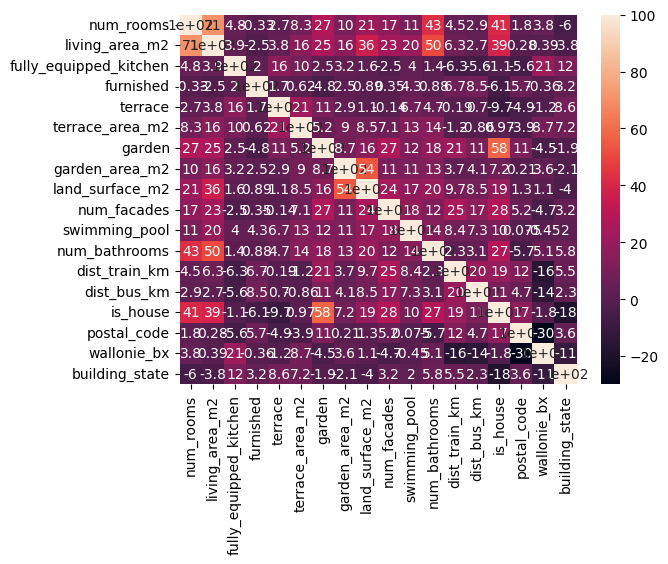

In [11]:
b = df.corr(numeric_only=True).drop(index=["price_eur"], columns=["price_eur"]) * 100

sns.heatmap(b, annot=True)
plt.show()

In [12]:
#Correlation with price graph 

a = df.corr(numeric_only=True)["price_eur"].drop(["price_eur","wallonie_bx","postal_code", "flandre"]).sort_values(ascending=False)
a.plot(kind="bar")
plt.title("Correlation with Price")
plt.xlabel("Variables")
plt.ylabel("Correlation coefficient")
plt.show()


KeyError: "['flandre'] not found in axis"

In [ ]:
# How many quantitative variables are there?

len(df.select_dtypes(include="number").columns)

In [ ]:
# How many quantitative variables are there?

len(df.select_dtypes(include="object").columns)

In [ ]:
#How would you transform these values into numerical values?

#pd.get_dummies(df, columns=["locality", "property_type", "subtype", "type_of_sale", "state_of_building"])


In [ ]:
#Percentage of missing values per column?
missings = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missings.plot(kind="bar")
plt.title("Percentage of missing values per column?")
plt.xlabel("Variables")
plt.ylabel("Percentage coefficient")
plt.show()

In [ ]:
#Creating Variables 

df["price_per_m2"] = df["price_eur"] / df["living_area_m2"]
df["price_per_m2"].mean()

In [ ]:
price_per_m2 = df.groupby("municipality")["price_per_m2"].mean().sort_values(ascending=False).head(10)

price_per_m2.plot(kind="bar")
plt.title("Price per m2 by municipality?")
plt.xlabel("Locality")
plt.ylabel("Price per m2")
plt.show()

STEP 3 : DATA INTERPRETATION

In [ ]:
#Plot the outliers 
outliers_price = df.sort_values("price_eur", ascending=False).head(10)

outliers_price.plot(kind="bar")
plt.title("Price outliers")
plt.xlabel("Index n°")
plt.ylabel("Price")
plt.legend().remove()
plt.show()

In [ ]:
#Which variables would you delete and why ?

"""  
df["garden_area_m2"] & df["terrace_area_m2"]

Too many missing values  """

In [ ]:
#Represent the number of properties according to their surface using a histogram
plt.figure(figsize=(10,5))
plt.hist(df["living_area_m2"], bins=50)
plt.title("Distribution of property prices")
plt.xlabel("Living Area m2")
plt.ylabel("Number of properties")
plt.show()

In [ ]:
#What are the most expensive municipalities in Belgium? (Average price, median price, price per square meter)

municipality_be = df.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
municipality_be.sort_values("avg_price", ascending=False).head(10)

In [ ]:
#What are the most expensive municipalities in Wallonia? (Average price, median price, price per square meter)
wallonia = df[df["wallonie_bx"] == 1]

wallonia_bx = wallonia.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
wallonia_bx.sort_values("avg_price", ascending=False).head(10)


In [ ]:
#What are the most expensive municipalities in Flanders? (Average price, median price, price per square meter)

flanders = df[df["flandre"] == 1]

flandre = flanders.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
flandre.sort_values("avg_price", ascending=False).head(10)

In [ ]:
#What are the less expensive municipalities in Belgium? (Average price, median price, price per square meter)

municipality_be = df.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
municipality_be.sort_values("avg_price", ascending=True).head(10)


In [ ]:
#What are the less expensive municipalities in Wallonia? (Average price, median price, price per square meter)

wallonia = df[df["wallonie_bx"] == 1]

wallonia_bx = wallonia.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
wallonia_bx.sort_values("avg_price", ascending=True).head(10)

In [ ]:
#What are the less expensive municipalities in Flanders? (Average price, median price, price per square meter)

flanders = df[df["flandre"] == 1]

flandre = flanders.groupby("municipality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    avg_price_per_m2=("price_per_m2", "mean")
)
flandre.sort_values("avg_price", ascending=True).head(10)